# Import Necessary Packages

In [ ]:
%pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 74.9 MB/s eta 0:00:00


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

import shap
from tqdm import tqdm

# Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
education_only_df = pd.read_csv('/content/drive/My Drive/IS_II/datasets/education_only_data.csv')
education_only_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518961 entries, 0 to 518960
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ENG.HS           518961 non-null  float64
 1   SC.HS            518961 non-null  float64
 2   MATH.HS          518961 non-null  float64
 3   CR.HS            518961 non-null  float64
 4   NS.HS            518961 non-null  float64
 5   degree           518961 non-null  object 
 6   degree.focus     518961 non-null  object 
 7   gender           518961 non-null  object 
 8   fems             518961 non-null  object 
 9   fefs             518961 non-null  object 
 10  int.s            518961 non-null  float64
 11  comp.s           518961 non-null  float64
 12  wasm.s           518961 non-null  float64
 13  car.s            518961 non-null  float64
 14  t.cred           518961 non-null  int64  
 15  t.parents        518961 non-null  int64  
 16  t.own            518961 non-null  int6

In [ ]:
numeric_columns = ['ENG.HS','SC.HS', 'MATH.HS', 'CR.HS', 'NS.HS','int.s', 'comp.s', 'wasm.s', 'car.s', 't.cred', 't.parents', 't.own']

# Preprocessing

### Map Degree Focus to Category

In [ ]:
# degree_focus_mapper.py

import pandas as pd

# --- Mapping dictionary according to your proposals ---

degree_focus_mapping = {
    # 2) Health & Clinical Sciences
    "MEDICINE": "HEALTH & CLINICAL SCIENCES",
    "NURSING": "HEALTH & CLINICAL SCIENCES",
    "PUBLIC HEALTH": "HEALTH & CLINICAL SCIENCES",
    "THERAPIES": "HEALTH & CLINICAL SCIENCES",
    "SURGICAL INSTRUMENTATION": "HEALTH & CLINICAL SCIENCES",
    "ODONTOLOGY": "HEALTH & CLINICAL SCIENCES",
    "OPTOMETRY AND OTHER HEALTH SCIENCES PROGRAMS": "HEALTH & CLINICAL SCIENCES",
    "NUTRITION AND DIET": "HEALTH & CLINICAL SCIENCES",
    "BACTERIOLOGY": "HEALTH & CLINICAL SCIENCES",
    "VETERINARY MEDICINE": "HEALTH & CLINICAL SCIENCES",

    # 3a) Engineering Groups
    "CIVIL ENGINEERING AND RELATED": "CORE ENGINEERING",
    "MECHANICAL AND RELATED ENGINEERING": "CORE ENGINEERING",
    "INDUSTRIAL AND RELATED ENGINEERING": "CORE ENGINEERING",
    "ADMINISTRATIVE AND RELATED ENGINEERING": "CORE ENGINEERING",

    "ELECTRONIC ENGINEERING, TELECOMMUNICATIONS AND RELATED": "ELECTRICAL & ELECTRONICS ENGINEERING",
    "ELECTRICAL AND RELATED ENGINEERING": "ELECTRICAL & ELECTRONICS ENGINEERING",

    "MINING, METALLURGY AND RELATED ENGINEERING": "SPECIALIZED ENGINEERING",
    "CHEMICAL AND RELATED ENGINEERING": "SPECIALIZED ENGINEERING",
    "BIOMEDICAL AND RELATED ENGINEERING": "SPECIALIZED ENGINEERING",
    "AGROINDUSTRIAL, FOOD AND RELATED ENGINEERING": "SPECIALIZED ENGINEERING",
    "OTHER ENGINEERING": "SPECIALIZED ENGINEERING",

    # 4) Business & Management
    "MANAGEMENT": "BUSINESS & MANAGEMENT",
    "PUBLIC ACCOUNTING": "BUSINESS & MANAGEMENT",
    "ECONOMY": "BUSINESS & MANAGEMENT",

    # 5) Arts & Design
    "DESIGN": "ARTS & DESIGN",
    "PLASTIC, VISUAL AND RELATED ARTS": "ARTS & DESIGN",
    "PERFORMING ARTS": "ARTS & DESIGN",
    "MUSIC": "ARTS & DESIGN",
    "OTHER PROGRAMS ASSOCIATED WITH FINE ARTS": "ARTS & DESIGN",

    # 6) Social Sciences & Humanities
    "SOCIOLOGY, SOCIAL WORK AND RELATED": "SOCIAL SCIENCES & HUMANITIES",
    "POLITICAL SCIENCE AND INTERNATIONAL RELATIONS": "SOCIAL SCIENCES & HUMANITIES",
    "ANTHROPOLOGY AND LIBERAL ARTS": "SOCIAL SCIENCES & HUMANITIES",
    "GEOGRAPHY AND HISTORY": "SOCIAL SCIENCES & HUMANITIES",
    "PHILOSOPHY, THEOLOGY AND RELATED": "SOCIAL SCIENCES & HUMANITIES",
    "MODERN LANGUAGES, LITERATURE, LINGUISTIC AND RELATED": "SOCIAL SCIENCES & HUMANITIES",

    # 7) Natural & Basic Sciences
    "BIOLOGY, MICROBIOLOGY AND RELATED": "NATURAL & BASIC SCIENCES",
    "CHEMISTRY AND RELATED": "NATURAL & BASIC SCIENCES",
    "PHYSICS": "NATURAL & BASIC SCIENCES",
    "GEOLOGY AND OTHER NATURAL SCIENCE PROGRAMS": "NATURAL & BASIC SCIENCES",
    "MATHEMATICS, STATISTICS AND RELATED": "NATURAL & BASIC SCIENCES",

    # 8) Agricultural & Environmental
    "AGRONOMY": "AGRICULTURE & ENVIRONMENTAL SCIENCES",
    "AGRICULTURAL, FORESTRY AND RELATED ENGINEERING": "AGRICULTURE & ENVIRONMENTAL SCIENCES",
    "AGRONOMICAL, LIVESTOCK AND RELATED ENGINERING": "AGRICULTURE & ENVIRONMENTAL SCIENCES",
    "AGROINDUSTRIAL, FOOD AND RELATED ENGINEERING": "AGRICULTURE & ENVIRONMENTAL SCIENCES",
    "ZOOTECHNICS": "AGRICULTURE & ENVIRONMENTAL SCIENCES",
    "ENVIRONMENTAL, SANITARY AND RELATED ENGINEERING": "AGRICULTURE & ENVIRONMENTAL SCIENCES",
}


# --- Function to apply mapping ---

def group_degree_focus(focus):
    """
    Maps a single degree focus or a pandas Series of focuses
    to grouped categories. Unmapped values go to 'OTHER / SPECIALIZED PROGRAMS'.
    """
    if isinstance(focus, pd.Series):
        return focus.map(lambda x: degree_focus_mapping.get(x, "OTHER / SPECIALIZED PROGRAMS"))
    elif isinstance(focus, list):
        return [degree_focus_mapping.get(x, "OTHER / SPECIALIZED PROGRAMS") for x in focus]
    else:
        return degree_focus_mapping.get(focus, "OTHER / SPECIALIZED PROGRAMS")


In [ ]:
education_only_df['degree.category'] = group_degree_focus(education_only_df['degree.focus'])

In [ ]:
education_only_df['degree.category'].value_counts()

,count
degree.category,
OTHER / SPECIALIZED PROGRAMS,178044
BUSINESS & MANAGEMENT,122558
CORE ENGINEERING,64155
HEALTH & CLINICAL SCIENCES,53614
AGRICULTURE & ENVIRONMENTAL SCIENCES,25271
SOCIAL SCIENCES & HUMANITIES,23940
ARTS & DESIGN,17891
SPECIALIZED ENGINEERING,12387
NATURAL & BASIC SCIENCES,10626


### Encoding and Standardization

In [ ]:
df_encoded = education_only_df.copy()
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518961 entries, 0 to 518960
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ENG.HS           518961 non-null  float64
 1   SC.HS            518961 non-null  float64
 2   MATH.HS          518961 non-null  float64
 3   CR.HS            518961 non-null  float64
 4   NS.HS            518961 non-null  float64
 5   degree           518961 non-null  object 
 6   degree.focus     518961 non-null  object 
 7   gender           518961 non-null  object 
 8   fems             518961 non-null  object 
 9   fefs             518961 non-null  object 
 10  int.s            518961 non-null  float64
 11  comp.s           518961 non-null  float64
 12  wasm.s           518961 non-null  float64
 13  car.s            518961 non-null  float64
 14  t.cred           518961 non-null  int64  
 15  t.parents        518961 non-null  int64  
 16  t.own            518961 non-null  int6

In [ ]:
# Define the categories for each column
categories_dict = {
    'fefs': sorted(education_only_df['fefs'].unique()),
    'fems': sorted(education_only_df['fems'].unique()),
    'gender': sorted(education_only_df['gender'].unique())
}

cat_columns = categories_dict.keys()


# Apply OrdinalEncoder to each column
encoder = OrdinalEncoder(categories=list(categories_dict.values()))
columns_to_encode = list(cat_columns)

# Fit and transform the columns
df_encoded[columns_to_encode] = encoder.fit_transform(education_only_df[columns_to_encode])

# One-hot encode fofu and fomu columns
# df_encoded = pd.get_dummies(df_encoded, columns=['fofu', 'fomu'])

In [ ]:
# Set degree as Target
# Y = df_encoded['degree.focus']
# X = df_encoded.drop(columns=['degree.focus'])

target = 'degree.category'

Y = df_encoded['degree.category']
X = df_encoded.drop(columns=['degree.focus', 'degree.category'])

# Separate features
X_num = X[numeric_columns]
X_cat = X[list(cat_columns)]

# Scale numerical features
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Encode target labels as integers
le = LabelEncoder()
Y = le.fit_transform(Y)

# Convert scaled numerical features back to DataFrame for easier splitting
X_num_scaled_df = pd.DataFrame(X_num_scaled, columns=numeric_columns, index=X_num.index)

### Train Test Split and Resampling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Split data into training and testing sets
X_train_num, X_test_num, X_train_cat, X_test_cat, y_train, y_test  = train_test_split(
    X_num_scaled_df, X_cat, Y, test_size=0.2, random_state=42
)

In [ ]:
def hybrid_median_balance_split(X_train, y_train):
    """
    Balances the training set by oversampling with SMOTE and undersampling
    so each class has the median class size. Test set remains unchanged.
    """
    counts = Counter(y_train)
    print("Original train class distribution:", counts)

    median_size = int(np.median(list(counts.values())))
    target_counts = {cls: median_size for cls in counts}

    # Oversample minority classes using SMOTE
    over_strategy = {cls: median_size for cls, cnt in counts.items() if cnt < median_size}
    if over_strategy:
        smote = SMOTE(sampling_strategy=over_strategy, random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)

    # Undersample majority classes
    under_strategy = {cls: median_size for cls, cnt in Counter(y_train).items() if cnt > median_size}
    if under_strategy:
        under = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
        X_train, y_train = under.fit_resample(X_train, y_train)

    print("Balanced train class distribution:", Counter(y_train))
    print("Test set remains unchanged:", Counter(y_test))

    return X_train, y_train

In [ ]:
# Combine numerical and categorical training data for resampling
X_train_combined = pd.concat([X_train_num, X_train_cat], axis=1)

X_train_resampled, y_train_resampled =  hybrid_median_balance_split(X_train_combined, y_train)

# Separate numerical and categorical features after resampling
X_train_resampled_num = X_train_resampled[numeric_columns]
X_train_resampled_cat = X_train_resampled[list(cat_columns)]

X_train_num = X_train_resampled_num
X_train_cat = X_train_resampled_cat
y_train = y_train_resampled

Original train class distribution: Counter({np.int64(7): 142276, np.int64(2): 98129, np.int64(3): 51298, np.int64(5): 42943, np.int64(0): 20175, np.int64(8): 19193, np.int64(1): 14259, np.int64(9): 9902, np.int64(6): 8527, np.int64(4): 8466})
Balanced train class distribution: Counter({np.int64(0): 19684, np.int64(1): 19684, np.int64(2): 19684, np.int64(3): 19684, np.int64(4): 19684, np.int64(5): 19684, np.int64(6): 19684, np.int64(7): 19684, np.int64(8): 19684, np.int64(9): 19684})
Test set remains unchanged: Counter({np.int64(7): 35768, np.int64(2): 24429, np.int64(3): 12857, np.int64(5): 10671, np.int64(0): 5096, np.int64(8): 4747, np.int64(1): 3632, np.int64(9): 2485, np.int64(6): 2099, np.int64(4): 2009})


In [ ]:
# Combine numerical and categorical training data for resampling
X_train_combined = pd.concat([X_train_num, X_train_cat], axis=1)

# Resampling to ensure class balance using RandomUnderSampler
print("Class distribution before resampling:", Counter(y_train))

# Apply RandomUnderSampler for undersampling
rus = RandomUnderSampler(random_state=42)
X_train_resampled_combined, y_train_resampled = rus.fit_resample(X_train_combined, y_train)

# Separate numerical and categorical features after resampling
X_train_resampled_num = X_train_resampled_combined[numeric_columns]
X_train_resampled_cat = X_train_resampled_combined[list(cat_columns)]

X_train_num = X_train_resampled_num
X_train_cat = X_train_resampled_cat
y_train = y_train_resampled

# Check class distribution after resampling
print("Class distribution after resampling:", Counter(y_train_resampled))

Class distribution before resampling: Counter({np.int64(0): 19684, np.int64(1): 19684, np.int64(2): 19684, np.int64(3): 19684, np.int64(4): 19684, np.int64(5): 19684, np.int64(6): 19684, np.int64(7): 19684, np.int64(8): 19684, np.int64(9): 19684})
Class distribution after resampling: Counter({np.int64(0): 19684, np.int64(1): 19684, np.int64(2): 19684, np.int64(3): 19684, np.int64(4): 19684, np.int64(5): 19684, np.int64(6): 19684, np.int64(7): 19684, np.int64(8): 19684, np.int64(9): 19684})


# Model Classes

In [ ]:
class StudentDataset(Dataset):
    def __init__(self, X_num, X_cat, y):
        self.cat_data = torch.tensor(X_cat.values, dtype=torch.long)
        self.num_data = torch.tensor(X_num.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat_data[idx], self.num_data[idx], self.y[idx]

In [ ]:
class DegreeRecommender(nn.Module):
    def __init__(self, cat_sizes, num_num_features, hidden_dim=128, num_classes=100):
        super().__init__()
        # Embeddings for categorical features
        self.emb_layers = nn.ModuleList([
            nn.Embedding(cat_size, min(50, (cat_size+1)//2)) for cat_size in cat_sizes
        ])
        emb_dim = sum([emb.embedding_dim for emb in self.emb_layers])

        self.fc1 = nn.Linear(emb_dim + num_num_features, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x_cat, x_num):
        embs = [emb(x_cat[:,i]) for i,emb in enumerate(self.emb_layers)]
        x = torch.cat(embs, dim=1)
        x = torch.cat([x, x_num], dim=1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        return self.out(x)

#  Training

In [ ]:
num_classes = df_encoded[target].nunique()
cat_sizes = [df_encoded[col].nunique() for col in cat_columns]
model_1 = DegreeRecommender(cat_sizes, len(numeric_columns), hidden_dim=128, num_classes=num_classes)

In [ ]:
train_ds_1 = StudentDataset(X_train_resampled_num, X_train_resampled_cat, pd.Series(y_train_resampled))
val_ds_1 = StudentDataset(X_test_num, X_test_cat, pd.Series(y_test))

train_loader_1 = DataLoader(train_ds_1, batch_size=512, shuffle=True)
val_loader_1 = DataLoader(val_ds_1, batch_size=512)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_1 = model_1.to(device)
device

'cpu'

In [ ]:
num_epochs = 25

In [ ]:
# criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_1.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-3,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader_1)
)

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device):
    loss_history = []
    top3_acc_history = []
    top5_acc_history = []
    top1_acc_history = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for cat, num, y in train_loader:
            cat, num, y = cat.to(device), num.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(cat, num)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        loss_history.append(avg_train_loss)

        # Validation Top-1, Top-5, and Top-3 accuracy
        model.eval()
        correct_top1, correct_top5, correct_top3, total = 0, 0, 0, 0
        with torch.no_grad():
            for cat, num, y in val_loader:
                cat, num, y = cat.to(device), num.to(device), y.to(device)
                logits = model(cat, num)

                # Top-1 accuracy
                top_preds_top1 = torch.topk(logits, 1, dim=1).indices.squeeze(1)
                correct_top1 += (top_preds_top1 == y).sum().item()

                # Top-3 accuracy
                topk_3 = 3
                top_preds_top3 = torch.topk(logits, topk_3, dim=1).indices
                correct_top3 += (top_preds_top3 == y.unsqueeze(1)).any(dim=1).sum().item()

                # Top-5 accuracy
                topk_5 = 5
                top_preds_top5 = torch.topk(logits, topk_5, dim=1).indices
                correct_top5 += (top_preds_top5 == y.unsqueeze(1)).any(dim=1).sum().item()


                total += y.size(0)

        top1_acc = correct_top1 / total
        top3_acc = correct_top3 / total
        top5_acc = correct_top5 / total


        scheduler.step(top3_acc)


        top1_acc_history.append(top1_acc)
        top3_acc_history.append(top3_acc)
        top5_acc_history.append(top5_acc)


        print(f"Epoch {epoch+1}, Loss {avg_train_loss:.4f}, Top-1 Acc {top1_acc:.4f}, Top-3 Acc {top3_acc:.4f}, Top-5 Acc {top5_acc:.4f}")

    return loss_history, top1_acc_history, top3_acc_history, top5_acc_history

In [ ]:
loss_history, top1_acc_history, top5_acc_history, top10_acc_history = train_model(
    model_1, train_loader_1, val_loader_1, criterion, optimizer, scheduler, num_epochs, device
)

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 1, Loss 2.1232, Top-1 Acc 0.1407, Top-3 Acc 0.4622, Top-5 Acc 0.7032
Epoch 2, Loss 2.1237, Top-1 Acc 0.1426, Top-3 Acc 0.4684, Top-5 Acc 0.7099
Epoch 3, Loss 2.1225, Top-1 Acc 0.1411, Top-3 Acc 0.4633, Top-5 Acc 0.7074
Epoch 4, Loss 2.1226, Top-1 Acc 0.1429, Top-3 Acc 0.4654, Top-5 Acc 0.7077
Epoch 5, Loss 2.1223, Top-1 Acc 0.1417, Top-3 Acc 0.4688, Top-5 Acc 0.7093
Epoch 6, Loss 2.1219, Top-1 Acc 0.1405, Top-3 Acc 0.4595, Top-5 Acc 0.7046
Epoch 7, Loss 2.1218, Top-1 Acc 0.1357, Top-3 Acc 0.4535, Top-5 Acc 0.6992
Epoch 8, Loss 2.1206, Top-1 Acc 0.1402, Top-3 Acc 0.4682, Top-5 Acc 0.7102
Epoch 9, Loss 2.1208, Top-1 Acc 0.1429, Top-3 Acc 0.4703, Top-5 Acc 0.7085
Epoch 10, Loss 2.1209, Top-1 Acc 0.1425, Top-3 Acc 0.4707, Top-5 Acc 0.7095
Epoch 11, Loss 2.1196, Top-1 Acc 0.1439, Top-3 Acc 0.4732, Top-5 Acc 0.7120
Epoch 12, Loss 2.1198, Top-1 Acc 0.1407, Top-3 Acc 0.4606, Top-5 Acc 0.7055
Epoch 13, Loss 2.1195, Top-1 Acc 0.1467, Top-3 Acc 0.4787, Top-5 Acc 0.7174
Epoch 14, Loss 2.1195

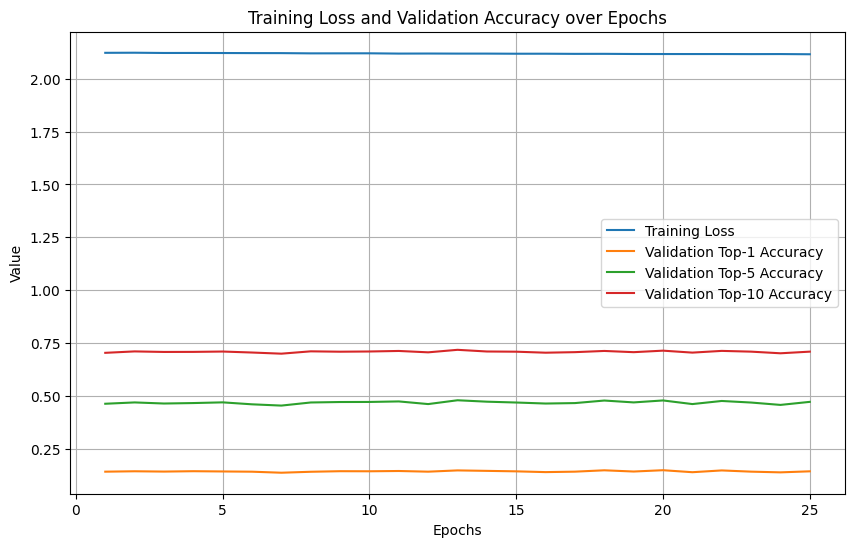

In [ ]:
epochs = range(1, len(loss_history) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_history, label='Training Loss')
plt.plot(epochs, top1_acc_history, label='Validation Top-1 Accuracy')
plt.plot(epochs, top5_acc_history, label='Validation Top-5 Accuracy')
plt.plot(epochs, top10_acc_history, label='Validation Top-10 Accuracy')
plt.title('Training Loss and Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Feature Importance

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_1.to(device)
model_1.eval()

DegreeRecommender(
  (emb_layers): ModuleList(
    (0-1): 2 x Embedding(11, 6)
    (2): Embedding(2, 1)
  )
  (fc1): Linear(in_features=25, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (out): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)

In [ ]:
# PERMUTATION FEATURE IMPORTANCE
def permutation_importance(model, X_val_num, X_val_cat, y_val, num_feature_names, cat_feature_names, device='cpu'):
    """
    Compute permutation feature importance for a PyTorch model.
    """
    # Convert pandas DataFrames to PyTorch tensors and move to device
    X_val_num_tensor = torch.tensor(X_val_num.values, dtype=torch.float32).to(device)
    X_val_cat_tensor = torch.tensor(X_val_cat.values, dtype=torch.long).to(device)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long).to(device)


    # Baseline accuracy
    with torch.no_grad():
        y_pred = model(X_val_cat_tensor, X_val_num_tensor).argmax(dim=1)
        baseline_acc = accuracy_score(y_val_tensor.cpu(), y_pred.cpu())

    print(f"🎯 Baseline Accuracy: {baseline_acc:.4f}")

    feature_importances = []
    # Permute numerical features
    X_val_num_np = X_val_num_tensor.cpu().numpy()
    for i, col in enumerate(tqdm(num_feature_names, desc="Calculating permutation importance for numerical features")):
        X_permuted = X_val_num_np.copy()
        np.random.shuffle(X_permuted[:, i])

        with torch.no_grad():
            y_pred_perm = model(X_val_cat_tensor, torch.tensor(X_permuted, dtype=torch.float32, device=device)).argmax(dim=1)
            perm_acc = accuracy_score(y_val_tensor.cpu(), y_pred_perm.cpu())

        importance = baseline_acc - perm_acc
        feature_importances.append({'Feature': col, 'Importance': importance})

    # Permute categorical features
    X_val_cat_np = X_val_cat_tensor.cpu().numpy()
    for i, col in enumerate(tqdm(cat_feature_names, desc="Calculating permutation importance for categorical features")):
        X_permuted = X_val_cat_np.copy()
        np.random.shuffle(X_permuted[:, i])

        with torch.no_grad():
            y_pred_perm = model(torch.tensor(X_permuted, dtype=torch.long, device=device), X_val_num_tensor).argmax(dim=1)
            perm_acc = accuracy_score(y_val_tensor.cpu(), y_pred_perm.cpu())

        importance = baseline_acc - perm_acc
        feature_importances.append({'Feature': col, 'Importance': importance})


    importance_df = pd.DataFrame(feature_importances).sort_values('Importance', ascending=False)

    return importance_df

🎯 Baseline Accuracy: 0.1423


Calculating permutation importance for numerical features: 100%|██████████| 12/12 [00:04<00:00,  2.83it/s]
Calculating permutation importance for categorical features: 100%|██████████| 3/3 [00:00<00:00,  3.76it/s]


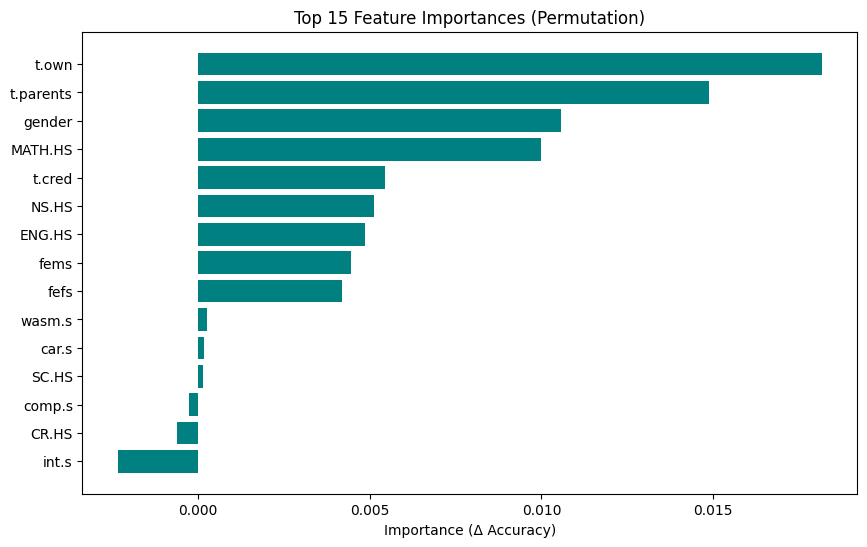

In [ ]:
# Run permutation importance
importance_df = permutation_importance(model_1, X_test_num, X_test_cat, y_test, numeric_columns, list(cat_columns), device)

# Plot top 15 permutation importances
plt.figure(figsize=(10, 6))
top_perm = importance_df.head(15)
plt.barh(top_perm['Feature'], top_perm['Importance'], color='teal')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Permutation)")
plt.xlabel("Importance (Δ Accuracy)")
plt.show()

In [ ]:
low_importance_features = importance_df[importance_df['Importance'] < 0.0001]
print("Features with importance less than 0.0001 (Permutation):")
display(low_importance_features)

Features with importance less than 0.0001 (Permutation):


,Feature,Importance
6,comp.s,-0.000270
3,CR.HS,-0.000607
5,int.s,-0.002341


# Training Dropping Unimportant Features

In [ ]:
# Identify features to drop
features_to_drop = low_importance_features['Feature'].tolist()
print(f"Features to be dropped: {features_to_drop}")

# Create new dataframes without the unimportant features
X_train_num_dropped = X_train_num.drop(columns=features_to_drop, errors='ignore')
X_test_num_dropped = X_test_num.drop(columns=features_to_drop, errors='ignore')

# Create new datasets and dataloaders
train_ds_dropped = StudentDataset(X_train_num_dropped, X_train_cat, pd.Series(y_train))
val_ds_dropped = StudentDataset(X_test_num_dropped, X_test_cat, pd.Series(y_test))

train_loader_dropped = DataLoader(train_ds_dropped, batch_size=512, shuffle=True)
val_loader_dropped = DataLoader(val_ds_dropped, batch_size=512)

Features to be dropped: ['comp.s', 'CR.HS', 'int.s']


In [ ]:
# Initialize a new model with adjusted input dimensions
num_num_features_dropped = X_train_num_dropped.shape[1]
model_dropped = DegreeRecommender(cat_sizes, num_num_features_dropped, hidden_dim=128, num_classes=num_classes)
model_dropped = model_dropped.to(device)

In [ ]:
# Define criterion, optimizer, and scheduler for the new model
# Using the same settings as before for consistency
criterion_dropped = nn.CrossEntropyLoss()
optimizer_dropped = optim.AdamW(model_dropped.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_dropped = optim.lr_scheduler.OneCycleLR(
    optimizer_dropped,
    max_lr=3e-3,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader_dropped)
)

In [ ]:
# Train the new model
loss_history_dropped, top1_acc_history_dropped, top5_acc_history_dropped, top10_acc_history_dropped = train_model(
    model_dropped, train_loader_dropped, val_loader_dropped, criterion_dropped, optimizer_dropped, scheduler_dropped, num_epochs, device
)

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 1, Loss 2.2290, Top-1 Acc 0.1506, Top-3 Acc 0.4676, Top-5 Acc 0.6947
Epoch 2, Loss 2.1633, Top-1 Acc 0.1423, Top-3 Acc 0.4555, Top-5 Acc 0.6954
Epoch 3, Loss 2.1516, Top-1 Acc 0.1416, Top-3 Acc 0.4647, Top-5 Acc 0.6993
Epoch 4, Loss 2.1467, Top-1 Acc 0.1438, Top-3 Acc 0.4697, Top-5 Acc 0.7003
Epoch 5, Loss 2.1442, Top-1 Acc 0.1459, Top-3 Acc 0.4766, Top-5 Acc 0.7066
Epoch 6, Loss 2.1415, Top-1 Acc 0.1466, Top-3 Acc 0.4776, Top-5 Acc 0.7079
Epoch 7, Loss 2.1400, Top-1 Acc 0.1464, Top-3 Acc 0.4743, Top-5 Acc 0.7089
Epoch 8, Loss 2.1383, Top-1 Acc 0.1433, Top-3 Acc 0.4738, Top-5 Acc 0.7053
Epoch 9, Loss 2.1379, Top-1 Acc 0.1411, Top-3 Acc 0.4671, Top-5 Acc 0.7004
Epoch 10, Loss 2.1367, Top-1 Acc 0.1371, Top-3 Acc 0.4609, Top-5 Acc 0.6961
Epoch 11, Loss 2.1356, Top-1 Acc 0.1399, Top-3 Acc 0.4677, Top-5 Acc 0.7033
Epoch 12, Loss 2.1352, Top-1 Acc 0.1404, Top-3 Acc 0.4672, Top-5 Acc 0.7048
Epoch 13, Loss 2.1348, Top-1 Acc 0.1435, Top-3 Acc 0.4727, Top-5 Acc 0.7041
Epoch 14, Loss 2.1339

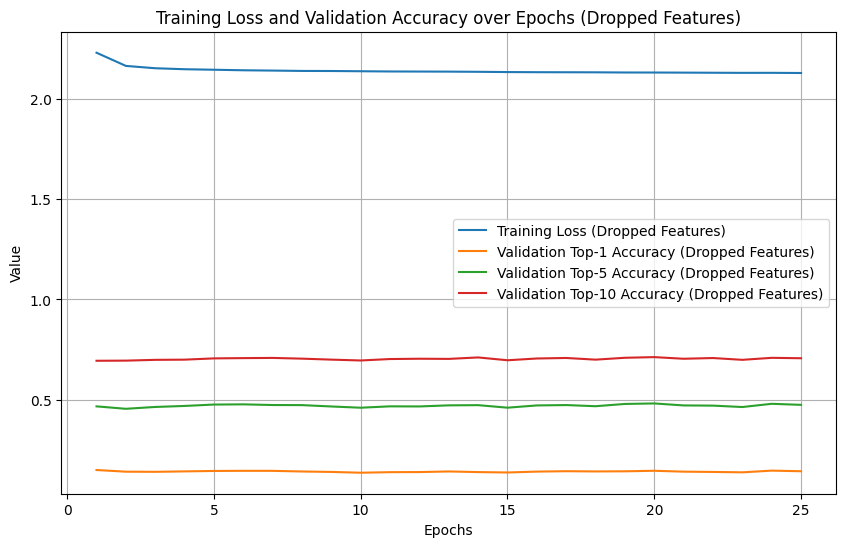

In [ ]:
# Visualize the results of the new model
epochs = range(1, len(loss_history_dropped) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_history_dropped, label='Training Loss (Dropped Features)')
plt.plot(epochs, top1_acc_history_dropped, label='Validation Top-1 Accuracy (Dropped Features)')
plt.plot(epochs, top5_acc_history_dropped, label='Validation Top-5 Accuracy (Dropped Features)')
plt.plot(epochs, top10_acc_history_dropped, label='Validation Top-10 Accuracy (Dropped Features)')
plt.title('Training Loss and Validation Accuracy over Epochs (Dropped Features)')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Analysis of Commonly Confused Degree Focuses

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure model is in evaluation mode
model_dropped.eval()

# Prepare test data tensors
X_test_num_dropped_tensor = torch.tensor(X_test_num_dropped.values, dtype=torch.float32).to(device)
X_test_cat_tensor = torch.tensor(X_test_cat.values, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)


# Run inference
with torch.no_grad():
    y_pred = model_dropped(X_test_cat_tensor, X_test_num_dropped_tensor).argmax(dim=1).cpu().numpy()
    y_true = y_test_tensor.cpu().numpy()

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Get class names from your label encoder (assuming 'le' encodes degree.focus)
labels = le.classes_

# Normalize confusion matrix to show proportions
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

print("Confusion matrix computed. Shape:", cm_normalized.shape)

Confusion matrix computed. Shape: (10, 10)


In [ ]:
cm_normalized

array([[0.08850078, 0.09654631, 0.08673469, 0.05592622, 0.19230769,
        0.13598901, 0.1244113 , 0.03728414, 0.12539246, 0.05690738],
       [0.02450441, 0.34636564, 0.04185022, 0.0597467 , 0.15446035,
        0.0996696 , 0.06470264, 0.03056167, 0.0814978 , 0.09664097],
       [0.05415694, 0.14130746, 0.19890294, 0.05190552, 0.12669368,
        0.12493348, 0.0749519 , 0.04146711, 0.13836015, 0.04732081],
       [0.05094501, 0.13261258, 0.05841176, 0.08617874, 0.29602551,
        0.09481216, 0.07217858, 0.02994478, 0.05918955, 0.11970133],
       [0.04678945, 0.09059233, 0.05126929, 0.09109009, 0.47237432,
        0.03036336, 0.05525137, 0.01791936, 0.03135889, 0.11299154],
       [0.03383001, 0.16680723, 0.05304095, 0.03870303, 0.10692531,
        0.24758692, 0.09699185, 0.02633305, 0.14562834, 0.08415331],
       [0.05812292, 0.14435445, 0.05145307, 0.0247737 , 0.24487851,
        0.07860886, 0.1291091 , 0.02000953, 0.09385422, 0.15483564],
       [0.05672668, 0.15684411, 0.1186535

In [ ]:
# Convert to DataFrame for easier interpretation
cm_df = pd.DataFrame(cm_normalized, index=labels, columns=labels)

# Exclude diagonal (correct predictions)
np.fill_diagonal(cm_df.values, 0)

# Find top 15 confusion pairs
confused_pairs = (
    cm_df.stack()
    .reset_index()
    .rename(columns={'level_0': 'True', 'level_1': 'Predicted', 0: 'ConfusionRate'})
    .sort_values('ConfusionRate', ascending=False)
    .head(15)
)

print("Top 15 Most Confused Degree Focus Pairs:")
print(confused_pairs)


Top 15 Most Confused Degree Focus Pairs:
                                    True  \
94               SPECIALIZED ENGINEERING   
34                      CORE ENGINEERING   
64              NATURAL & BASIC SCIENCES   
4   AGRICULTURE & ENVIRONMENTAL SCIENCES   
81          SOCIAL SCIENCES & HUMANITIES   
51            HEALTH & CLINICAL SCIENCES   
78          OTHER / SPECIALIZED PROGRAMS   
75          OTHER / SPECIALIZED PROGRAMS   
71          OTHER / SPECIALIZED PROGRAMS   
69              NATURAL & BASIC SCIENCES   
14                         ARTS & DESIGN   
58            HEALTH & CLINICAL SCIENCES   
61              NATURAL & BASIC SCIENCES   
21                 BUSINESS & MANAGEMENT   
74          OTHER / SPECIALIZED PROGRAMS   

                               Predicted  ConfusionRate  
94  ELECTRICAL & ELECTRONICS ENGINEERING       0.307847  
34  ELECTRICAL & ELECTRONICS ENGINEERING       0.296026  
64  ELECTRICAL & ELECTRONICS ENGINEERING       0.244879  
4   ELECTRICAL & ELECT

In [ ]:
# Calculate and display Top-5 and Top-3 accuracy for each degree focus

top3_acc_per_class = {}
top5_acc_per_class = {}

# Ensure model is in evaluation mode
model_dropped.eval()

# Prepare test data tensors (using the tensors from the previous confusion matrix calculation)
X_test_num_dropped_tensor = torch.tensor(X_test_num_dropped.values, dtype=torch.float32).to(device)
X_test_cat_tensor = torch.tensor(X_test_cat.values, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)


# Run inference to get logits
with torch.no_grad():
    logits = model_dropped(X_test_cat_tensor, X_test_num_dropped_tensor)
    y_true_tensor = y_test_tensor

# Iterate through each class
for i, class_name in enumerate(labels):
    # Get indices where the true label is the current class
    indices = (y_true_tensor == i).nonzero(as_tuple=True)[0]

    if len(indices) > 0:
        # Get the logits and true labels for the current class
        class_logits = logits[indices]
        class_y_true = y_true_tensor[indices]

        # Calculate Top-3 accuracy for the current class
        topk_3 = 3
        top_preds_top3 = torch.topk(class_logits, topk_3, dim=1).indices
        correct_top3 = (top_preds_top3 == class_y_true.unsqueeze(1)).any(dim=1).sum().item()
        top3_acc = correct_top3 / len(class_y_true)
        top3_acc_per_class[class_name] = top3_acc


        # Calculate Top-5 accuracy for the current class
        topk_5 = 5
        top_preds_top5 = torch.topk(class_logits, topk_5, dim=1).indices
        correct_top5 = (top_preds_top5 == class_y_true.unsqueeze(1)).any(dim=1).sum().item()
        top5_acc = correct_top5 / len(class_y_true)
        top5_acc_per_class[class_name] = top5_acc

    else:
        top3_acc_per_class[class_name] = 0.0
        top5_acc_per_class[class_name] = 0.0

# Display the results
print("Top-3 Accuracy Per Degree Focus:")
for class_name, acc in top3_acc_per_class.items():
    print(f"- {class_name}: {acc:.4f}")

print("\nTop-5 Accuracy Per Degree Focus:")
for class_name, acc in top5_acc_per_class.items():
    print(f"- {class_name}: {acc:.4f}")

Top-3 Accuracy Per Degree Focus:
- AGRICULTURE & ENVIRONMENTAL SCIENCES: 0.4095
- ARTS & DESIGN: 0.5245
- BUSINESS & MANAGEMENT: 0.3725
- CORE ENGINEERING: 0.4506
- ELECTRICAL & ELECTRONICS ENGINEERING: 0.6934
- HEALTH & CLINICAL SCIENCES: 0.4902
- NATURAL & BASIC SCIENCES: 0.4555
- OTHER / SPECIALIZED PROGRAMS: 0.5265
- SOCIAL SCIENCES & HUMANITIES: 0.5469
- SPECIALIZED ENGINEERING: 0.5759

Top-5 Accuracy Per Degree Focus:
- AGRICULTURE & ENVIRONMENTAL SCIENCES: 0.7747
- ARTS & DESIGN: 0.6949
- BUSINESS & MANAGEMENT: 0.6590
- CORE ENGINEERING: 0.6930
- ELECTRICAL & ELECTRONICS ENGINEERING: 0.7780
- HEALTH & CLINICAL SCIENCES: 0.7477
- NATURAL & BASIC SCIENCES: 0.6656
- OTHER / SPECIALIZED PROGRAMS: 0.7213
- SOCIAL SCIENCES & HUMANITIES: 0.7211
- SPECIALIZED ENGINEERING: 0.7127


# Export Models

In [ ]:
# Directory to store model
save_dir = "/content/trained_models"
os.makedirs(save_dir, exist_ok=True)

# Save both weights and metadata
model_path = os.path.join(save_dir, "degree_focus_model.pth")
metadata_path = os.path.join(save_dir, "degree_focus_metadata.pt")

# Save model weights
torch.save(model_1.state_dict(), model_path)


# Ensure objects are serializable
metadata = {
    "label_encoder_classes": list(le.classes_),
    "numeric_columns": list(numeric_columns) if not isinstance(numeric_columns, list) else numeric_columns,
    "categorical_columns": list(cat_columns) if not isinstance(cat_columns, list) else cat_columns,
}

# Save metadata (safe for all Python types)
torch.save(metadata, metadata_path)

print(f"✅ Model and metadata saved to: {save_dir}")

✅ Model and metadata saved to: /content/trained_models


In [ ]:
from google.colab import files
files.download(model_path)
files.download(metadata_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Export the model


## Pth

In [ ]:
# Directory to store model
save_dir = "/content/trained_models"
os.makedirs(save_dir, exist_ok=True)

# Define file paths
model_path = os.path.join(save_dir, "degree_focus_model_dropped_features.pth")
metadata_path = os.path.join(save_dir, "degree_focus_metadata_dropped_features.pt")

# Save model weights
torch.save(model_dropped.state_dict(), model_path)

# Ensure objects are serializable
metadata = {
    "label_encoder_classes": list(le.classes_),
    "numeric_columns": list(X_train_num_dropped.columns),
    "categorical_columns": list(X_train_cat.columns),
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "cat_sizes": cat_sizes
}

# Save metadata
torch.save(metadata, metadata_path)

print(f"✅ Model and metadata saved to: {save_dir}")

✅ Model and metadata saved to: /content/trained_models


## ONNX

In [ ]:
# Directory to store model
save_dir = "/content/drive/My Drive/IS_II/exported_nn_onnx"
os.makedirs(save_dir, exist_ok=True)

# Define file paths
model_path = os.path.join(save_dir, "degree_focus_model_dropped_features.pth")
metadata_path = os.path.join(save_dir, "degree_focus_metadata_dropped_features.json")
onnx_path = os.path.join(save_dir, "degree_focus_model_dropped_features.onnx")

# Save model weights
torch.save(model_dropped.state_dict(), model_path)

# Ensure objects are serializable
metadata = {
    "label_encoder_classes": list(le.classes_),
    "numeric_columns": list(X_train_num_dropped.columns),
    "categorical_columns": list(X_train_cat.columns),
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "cat_sizes": cat_sizes
}

# Save metadata
torch.save(metadata, metadata_path)

# Export model to ONNX
model_dropped.eval() # Set model to evaluation mode

# Create dummy input tensors for ONNX export
# Create a list of dummy categorical input tensors, one for each categorical feature
dummy_cat_inputs = [torch.randint(0, size, (1,), dtype=torch.long).to(device) for size in cat_sizes]
dummy_cat_input = torch.stack(dummy_cat_inputs, dim=1)

dummy_num_input = torch.randn(1, X_train_num_dropped.shape[1]).to(device)

torch.onnx.export(
    model_dropped,
    (dummy_cat_input, dummy_num_input),
    onnx_path,
    export_params=True,
    opset_version=11, # Choose an appropriate opset version
    do_constant_folding=True,
    input_names=['categorical_input', 'numerical_input'],
    output_names=['output'],
    dynamic_axes={
        'categorical_input': {0: 'batch_size'},
        'numerical_input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

print(f"✅ Model weights saved to: {model_path}")
print(f"✅ Metadata saved to: {metadata_path}")
print(f"✅ Model exported to ONNX: {onnx_path}")

✅ Model weights saved to: /content/drive/My Drive/IS_II/exported_nn_onnx/degree_focus_model_dropped_features.pth
✅ Metadata saved to: /content/drive/My Drive/IS_II/exported_nn_onnx/degree_focus_metadata_dropped_features.json
✅ Model exported to ONNX: /content/drive/My Drive/IS_II/exported_nn_onnx/degree_focus_model_dropped_features.onnx


/tmp/ipython-input-589352351.py:36: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


In [ ]:
import json

metadata_json_path = os.path.join(save_dir, "metadata.json")

with open(metadata_json_path, "w") as f:
    json.dump(metadata, f)

print(f"✅ Metadata saved to JSON: {metadata_json_path}")

✅ Metadata saved to JSON: /content/drive/My Drive/IS_II/exported_nn_onnx/metadata.json


## Test exported model

In [ ]:
# Load the saved model and metadata
model_path = "/content/drive/My Drive/IS_II/exported_nn_onnx/degree_focus_model_dropped_features.pth"
metadata_path = "/content/drive/My Drive/IS_II/exported_nn_onnx/degree_focus_metadata_dropped_features.pt"

# Load metadata first
metadata = torch.load(metadata_path)
label_encoder_classes = metadata["label_encoder_classes"]
numeric_columns_loaded = metadata["numeric_columns"]
categorical_columns_loaded = metadata["categorical_columns"]
scaler_mean_loaded = metadata["scaler_mean"]
scaler_scale_loaded = metadata["scaler_scale"]
cat_sizes_loaded = metadata["cat_sizes"]


# Initialize the model architecture
num_num_features_loaded = len(numeric_columns_loaded)
num_classes_loaded = len(label_encoder_classes)
model_loaded = DegreeRecommender(cat_sizes_loaded, num_num_features_loaded, hidden_dim=128, num_classes=num_classes_loaded)

# Load the saved state dictionary
model_loaded.load_state_dict(torch.load(model_path, map_location=device))
model_loaded.to(device)
model_loaded.eval() # Set the model to evaluation mode

print("✅ Model and metadata loaded successfully.")

# --- Create Dummy New Student Data ---
# Create a dictionary with sample data, ensuring columns match the training data structure
# Use the original column names before dropping features for creating the dummy data
# Then drop the unimportant features after creating the dummy data
dummy_data = {
    'ENG.HS': [85.0, 70.0, 92.0],
    'SC.HS': [78.0, 88.0, 76.0],
    'MATH.HS': [90.0, 75.0, 88.0],
    'CR.HS': [88.0, 72.0, 95.0],
    'NS.HS': [80.0, 85.0, 70.0],
    'int.s': [4.5, 3.8, 4.9],
    'comp.s': [3.2, 4.1, 3.5],
    'wasm.s': [4.0, 3.5, 4.2],
    'car.s': [3.9, 4.0, 3.7],
    't.cred': [120, 110, 130],
    't.parents': [2, 1, 3],
    't.own': [1, 0, 2],
    'fefs': ['YES', 'NO', 'YES'],
    'fems': ['YES', 'NO', 'YES'],
    'gender': ['MALE', 'FEMALE', 'FEMALE']
}

dummy_df = pd.DataFrame(dummy_data)

# Separate numeric and categorical columns from the dummy data
dummy_num = dummy_df[numeric_columns] # Use original numeric_columns list
dummy_cat = dummy_df[list(cat_columns)] # Use original cat_columns list

# Drop the features that were dropped during training
dummy_num_dropped = dummy_num.drop(columns=features_to_drop, errors='ignore')

# --- Preprocess the Dummy Data ---
# Apply the same scaler used during training
scaler_loaded = StandardScaler()
scaler_loaded.mean_ = np.array(scaler_mean_loaded)
scaler_loaded.scale_ = np.array(scaler_scale_loaded)
dummy_num_scaled = scaler_loaded.transform(dummy_num_dropped)


# Apply the same ordinal encoder used during training
# Recreate the encoder with the loaded categories dictionary
encoder_loaded = OrdinalEncoder(categories=list(categories_dict.values()))
# Fit the encoder on the original training data's categorical columns to ensure it has the correct mapping
# This is crucial if the dummy data doesn't contain all categories
encoder_loaded.fit(education_only_df[list(cat_columns)]) # Use original df for fitting
dummy_cat_encoded = encoder_loaded.transform(dummy_cat)


# Convert processed data to tensors
dummy_num_tensor = torch.tensor(dummy_num_scaled, dtype=torch.float32).to(device)
dummy_cat_tensor = torch.tensor(dummy_cat_encoded, dtype=torch.long).to(device)

print("✅ Dummy data preprocessed.")

# --- Make Predictions ---
with torch.no_grad():
    logits = model_loaded(dummy_cat_tensor, dummy_num_tensor)
    probabilities = torch.softmax(logits, dim=1)

# Get the top predicted class indices
top_preds_indices = torch.topk(probabilities, 1, dim=1).indices.squeeze(1).cpu().numpy()

# Get the top 3 predicted class indices and probabilities
top3_preds_probs = torch.topk(probabilities, 3, dim=1)
top3_preds_indices = top3_preds_probs.indices.cpu().numpy()
top3_preds_probabilities = top3_preds_probs.values.cpu().numpy()

# Map predicted indices back to class names
predicted_classes = [label_encoder_classes[idx] for idx in top_preds_indices]

print("\n--- Predictions for Dummy Data ---")
for i in range(len(dummy_df)):
    print(f"\nStudent {i+1}:")
    print(f"  Predicted Degree Focus: {predicted_classes[i]}")
    print("  Top 3 Predictions:")
    for j in range(3):
        predicted_class_name = label_encoder_classes[top3_preds_indices[i, j]]
        probability = top3_preds_probabilities[i, j]
        print(f"    - {predicted_class_name}: {probability:.4f}")

KeyError: 'scaler_mean'

### 1. Import Necessary Packages

This section imports all the required Python libraries for data manipulation, numerical operations, machine learning, and deep learning. Key libraries include:

*   `os`, `torch`, `torch.nn`, `torch.optim`, `torch.utils.data`: For building and training the neural network with PyTorch.
*   `numpy`, `pandas`: For numerical operations and data manipulation.
*   `seaborn`, `matplotlib.pyplot`: For data visualization.
*   `sklearn.model_selection`, `sklearn.metrics`, `sklearn.preprocessing`: For data splitting, evaluation metrics, and feature encoding/scaling.
*   `imblearn.under_sampling`, `imblearn.over_sampling`: For handling imbalanced datasets (undersampling and oversampling).
*   `collections.Counter`: For counting class distributions.
*   `tqdm`: For displaying progress bars during training.
*   `shap`: For explaining model predictions (though not directly used in the final explanation, it's imported).
*   `onnx`: For exporting the trained model to ONNX format.

### 2. Load Dataset

This section mounts Google Drive to access the dataset and then loads the `education_only_data.csv` file into a pandas DataFrame named `education_only_df`. The `.info()` method is used to display a summary of the DataFrame, including the number of entries, columns, non-null values, data types, and memory usage. This initial inspection helps in understanding the data's structure and identifying any missing values or incorrect data types.

### 3. Preprocessing

This crucial step prepares the raw data for model training. It involves several sub-steps:

1.  **Map Degree Focus to Category**: A Python dictionary (`degree_focus_mapping`) is defined to group specific `degree.focus` values into broader `degree.category` labels. This helps to reduce the number of unique target classes, potentially simplifying the classification task. A `group_degree_focus` function is created to apply this mapping, and any `degree.focus` not explicitly mapped is assigned to 'OTHER / SPECIALIZED PROGRAMS'. The `.value_counts()` method is then used to inspect the distribution of the newly created `degree.category`.

2.  **Encoding and Standardization**:
    *   A copy of the DataFrame `education_only_df` is made as `df_encoded`.
    *   Categorical features (`fefs`, `fems`, `gender`) are identified, and `OrdinalEncoder` is used to convert them into numerical representations. This is necessary because neural networks require numerical inputs.
    *   The `degree.category` column is chosen as the target variable (`Y`), and it's encoded into integers using `LabelEncoder`.
    *   Numerical features (`ENG.HS`, `SC.HS`, `MATH.HS`, etc.) are separated and scaled using `StandardScaler`. Standardization ensures that all numerical features contribute equally to the model's learning process by having zero mean and unit variance. The scaled numerical features are then converted back into a DataFrame.

### 4. Train Test Split and Resampling

This section focuses on preparing the data for model training and evaluation, particularly addressing class imbalance:

1.  **Train-Test Split**: The dataset is split into training and testing sets using `train_test_split`. 80% of the data is used for training and 20% for testing, with `random_state=42` ensuring reproducibility.

2.  **Hybrid Median Balance Split**: A custom function `hybrid_median_balance_split` is defined to balance the training set. It calculates the median class size and then uses `SMOTE` (Synthetic Minority Oversampling Technique) to oversample minority classes and `RandomUnderSampler` to undersample majority classes, aiming for each class to have the median number of samples. This helps prevent the model from being biased towards majority classes and improves its ability to learn from minority classes.

3.  **Applying Resampling**: The `hybrid_median_balance_split` function is applied to the training data. The numerical and categorical features are combined before resampling and then separated again into `X_train_num`, `X_train_cat`, and `y_train` after resampling. The class distribution is printed before and after resampling to confirm the balancing effect.

### 5. Model Classes

This section defines the core components of the neural network:

1.  **`StudentDataset` Class**: This custom `Dataset` class is designed to handle the input data for PyTorch. It takes numerical features (`X_num`), categorical features (`X_cat`), and target labels (`y`). It converts these pandas DataFrames/Series into PyTorch tensors, making them compatible with PyTorch's `DataLoader`. The `__len__` method returns the total number of samples, and `__getitem__` retrieves a single sample by index.

2.  **`DegreeRecommender` Class**: This is the neural network model definition. It inherits from `torch.nn.Module`:
    *   **Embeddings**: For each categorical feature, an `nn.Embedding` layer is created. Embedding layers convert discrete categorical inputs into dense, continuous vector representations, which can better capture relationships between categories than one-hot encoding for high-cardinality features.
    *   **Fully Connected Layers**: The embedded categorical features are concatenated with the numerical features. This combined feature vector is then passed through two fully connected (dense) layers (`nn.Linear`) with `ReLU` activation functions, which introduce non-linearity. Dropout is applied after the first hidden layer to prevent overfitting.
    *   **Output Layer**: The final `nn.Linear` layer outputs raw scores (logits) for each possible degree category. The number of output neurons (`num_classes`) matches the number of unique degree categories.

### 6. Training

This section sets up and executes the training process for the neural network:

1.  **Model Initialization**: An instance of `DegreeRecommender` is created, passing the sizes of categorical feature vocabularies, the number of numerical features, and the number of output classes. The model is moved to the appropriate device (CPU or GPU if available).

2.  **DataLoaders**: `StudentDataset` instances are created for both training and validation data (`train_ds_1`, `val_ds_1`), and then `DataLoader` objects are created from these datasets. `DataLoader` handles batching, shuffling (for training), and loading data efficiently during the training loop.

3.  **Loss Function, Optimizer, and Scheduler**:
    *   **`nn.CrossEntropyLoss()`**: This is chosen as the loss function, suitable for multi-class classification problems. It combines `LogSoftmax` and `NLLLoss` in one single class.
    *   **`optim.AdamW()`**: The AdamW optimizer is used, which is an adaptive learning rate optimization algorithm with weight decay (L2 regularization) to prevent overfitting.
    *   **`optim.lr_scheduler.OneCycleLR()`**: A learning rate scheduler is employed to dynamically adjust the learning rate during training, typically starting with a low learning rate, increasing it, and then decreasing it again. This often helps in achieving better convergence and performance.

4.  **`train_model` Function**: This function encapsulates the training and validation loop:
    *   It iterates for a specified number of `num_epochs`.
    *   In each epoch, it performs a training phase (sets model to `train()` mode, calculates loss, performs backpropagation, and updates weights).
    *   It then performs a validation phase (sets model to `eval()` mode, calculates Top-1, Top-3, and Top-5 accuracy without gradient updates).
    *   The learning rate scheduler's step method is called based on validation accuracy (or a similar metric) to adjust the learning rate.
    *   Loss and accuracy histories are recorded and printed for each epoch.

### 7. Feature Importance

This section assesses the importance of each input feature using the permutation importance method:

1.  **`permutation_importance` Function**: This function calculates permutation importance:
    *   It first determines a baseline accuracy of the model on the validation set.
    *   For each feature (numerical and categorical), it shuffles the values of that single feature in the validation set, keeping all other features intact.
    *   It then re-evaluates the model's accuracy. The drop in accuracy compared to the baseline indicates the importance of that feature. A larger drop means the feature is more important.
    *   The process is repeated for all features, and the results are returned as a DataFrame sorted by importance.

2.  **Execution and Visualization**: The `permutation_importance` function is called, and the resulting `importance_df` is printed and visualized using a horizontal bar plot to show the top 15 most important features. Features with very low importance (less than 0.0001) are identified and displayed.

### 8. Training Dropping Unimportant Features

Based on the permutation importance analysis, features identified as having very low importance are removed, and the model is retrained:

1.  **Feature Identification**: The features with importance less than 0.0001 (e.g., 'comp.s', 'CR.HS', 'int.s') are collected into a `features_to_drop` list.

2.  **Data Preparation**: New versions of the training and testing numerical data (`X_train_num_dropped`, `X_test_num_dropped`) are created by dropping these unimportant columns. The categorical data remains unchanged.

3.  **New Datasets and DataLoaders**: New `StudentDataset` and `DataLoader` objects are created using the reduced feature sets.

4.  **New Model Initialization and Training**: A new `DegreeRecommender` model (`model_dropped`) is initialized with the adjusted number of numerical features. The same criterion, optimizer, and scheduler settings are used. The model is then retrained using the `train_model` function with the new data loaders.

5.  **Visualization**: The training loss and validation accuracies (Top-1, Top-3, Top-5) of this new model are plotted to observe its performance compared to the original model. The goal is to see if removing uninformative features improves or maintains performance, potentially leading to a simpler and more efficient model.

### 9. Analysis of Commonly Confused Degree Focuses

This section delves into a detailed analysis of the model's performance for each specific degree category, especially focusing on where it makes mistakes:

1.  **Confusion Matrix**:
    *   The `model_dropped` is set to evaluation mode (`.eval()`).
    *   Predictions are made on the test set, and a confusion matrix (`cm`) is computed using `sklearn.metrics.confusion_matrix`. The confusion matrix shows the counts of true labels versus predicted labels.
    *   The matrix is then normalized (`cm_normalized`) to show proportions, which helps in understanding misclassification rates for each class.
    *   The diagonal elements (correct predictions) are set to zero to highlight misclassifications.

2.  **Top 15 Most Confused Pairs**: The normalized confusion matrix is converted into a pandas DataFrame. By stacking and sorting, the top 15 pairs of `(True_Label, Predicted_Label)` with the highest confusion rates (i.e., where the model most frequently confuses one class for another) are identified and printed. This provides insights into which degree categories are most difficult for the model to distinguish.

3.  **Top-3 and Top-5 Accuracy Per Class**:
    *   The model makes predictions on the test set, and the `logits` (raw output scores) are obtained.
    *   For each degree category, the code iterates through the samples belonging to that class.
    *   It then calculates the Top-3 and Top-5 accuracy specifically for that class. Top-K accuracy means that if the true label is among the top K predictions made by the model, it is considered a correct prediction. This is particularly useful in multi-class problems where a single correct answer might be too strict, and being able to recommend a few relevant options is acceptable. These per-class accuracies help pinpoint which categories the model struggles with the most, even if it gets the top-1 prediction wrong but gets it within the top 3 or top 5.

### 10. Export Models

This section focuses on saving the trained model and its associated metadata for future use or deployment:

1.  **Directory Setup**: A directory `/content/trained_models` is created to store the exported files.

2.  **Saving PTH Model**: The state dictionary (weights and biases) of the `model_dropped` (the retrained model with dropped features) is saved using `torch.save()` to a `.pth` file (`degree_focus_model_dropped_features.pth`). This is the standard way to save PyTorch models.

3.  **Saving Metadata (JSON)**: Important information required to recreate and use the model is saved:
    *   `label_encoder_classes`: The mapping from integer labels back to human-readable degree category names.
    *   `numeric_columns`: The names of the numerical features used.
    *   `categorical_columns`: The names of the categorical features used.
    *   `scaler_mean`, `scaler_scale`: Parameters of the `StandardScaler` used for numerical features. These are crucial for preprocessing new incoming data consistently.
    *   `cat_sizes`: The vocabulary sizes for each categorical embedding layer.
    This metadata is saved both as a `.pt` file (using `torch.save()`) and as a `.json` file (`metadata.json`). The JSON format is often preferred for metadata as it is human-readable and easily interoperable with different programming environments.

4.  **Exporting to ONNX**:
    *   The model is also exported to the ONNX (Open Neural Network Exchange) format. ONNX is an open standard that defines a common set of operators and an open file format for representing deep learning models. This allows models trained in one framework (like PyTorch) to be easily deployed in another framework or optimized with ONNX runtime.
    *   Dummy input tensors (one for categorical features and one for numerical features) are created to define the input shape for the ONNX graph.
    *   `torch.onnx.export` is used to convert the PyTorch model to an `.onnx` file, specifying input/output names and dynamic axes for flexible batch sizing.

### 11. Test Exported Model

This final section demonstrates how to load the saved model and metadata, and then use it to make predictions on new, unseen data:

1.  **Loading Model and Metadata**:
    *   The `.pth` model weights and the metadata (`.pt` file) are loaded.
    *   The `DegreeRecommender` class is re-instantiated using the loaded metadata (e.g., `cat_sizes`, `num_num_features`) to ensure the model architecture matches the saved weights.
    *   The loaded weights are then applied to the new model instance using `model_loaded.load_state_dict()`. The model is moved to the appropriate device and set to evaluation mode.

2.  **Dummy New Student Data**: A sample DataFrame `dummy_df` is created, simulating new student data. This data contains both numerical and categorical features, mimicking the original dataset structure.

3.  **Preprocessing Dummy Data**: The dummy data undergoes the exact same preprocessing steps as the training data:
    *   Numerical features are scaled using the *same `StandardScaler` parameters* (`scaler_mean_loaded`, `scaler_scale_loaded`) that were used during training.
    *   Categorical features are encoded using the *same `OrdinalEncoder`* (re-initialized with the original `categories_dict`) to ensure consistent mapping.
    *   The processed numerical and categorical data are converted into PyTorch tensors.

4.  **Making Predictions**: The `model_loaded` makes predictions on the preprocessed dummy data. `torch.softmax` is applied to the raw logits to obtain probabilities for each class.

5.  **Interpreting Predictions**:
    *   The top predicted class (Top-1) for each dummy student is identified and mapped back to its human-readable name using the `label_encoder_classes`.
    *   The top 3 predicted classes and their corresponding probabilities are also extracted and displayed, providing a more comprehensive recommendation.